# Práctica Sesión 3 — Encontrar los spikes

**De la neurona a la figura · Análisis neuronal en insectos asistido por IA**

Un electrodo extracelular casi nunca escucha a **una sola** neurona: escucha a las que tiene cerca.
Las que están más cerca del electrodo producen spikes **más grandes**.

Vas a trabajar con una señal **limpia y simulada** que contiene dos neuronas, y vas a recorrer
el camino completo:

1. Generar la señal y **mirarla** antes de tocarla.
2. Poner un **umbral** y justificarlo.
3. Convertir los cruces de umbral en una **lista de tiempos de spike**.
4. Usar la **amplitud** para separar las dos neuronas.
5. Contar spikes y calcular la **tasa de disparo** de cada una.

Aquí **el código lo escribes tú**. Lo que te damos es la
señal, la especificación de cada función y una forma de comprobar si lo que hiciste funciona.

⏱️ Duración: ~45 minutos, en parejas.

## Cómo funciona este taller

Hay tres tipos de ejercicio. El icono te dice qué te toca hacer:

| | Ejercicio | Qué haces |
|---|---|---|
| ✏️ | **Completa el código** | La celda tiene huecos marcados con `____`. El código **no corre** hasta que los llenes todos. |
| 📋 | **Pega este prompt** | Copia el prompt tal cual en ChatGPT o Claude, lee la respuesta y decide si sirve antes de usarla. |
| ✍️ | **Escribe tu prompt** | Lo redactas tú, con los 5 elementos de abajo. Escríbelo en la celda de texto: hace parte de la entrega. |

Después de los ejercicios numéricos hay una celda de **✅ verificación**: te dice si tu resultado
es correcto, pero no cómo llegar a él.

### Los 5 elementos de un prompt de programación

1. **Lenguaje.** Python. (Basta decirlo una vez, al inicio del chat.)
2. **Tipo de tarea.** Graficar, filtrar, seleccionar, cargar, calcular.
3. **Subtipo de tarea.** Line plot, histograma, umbral con `np.where`, período muerto.
4. **Tipo de datos.** *"Un array de numpy `senal` con 40 000 muestras de voltaje en µV, muestreado a 20 000 Hz, donde los spikes son picos negativos."*
5. **Exigencias de calidad.** Ejes rotulados con unidades, que explique qué hace cada línea, que no use librerías extra.

⚠️ Regla del curso: **nunca pegues código que no puedas explicar en voz alta.** En el proyecto
final te vamos a preguntar por tu propio código.

## Antes de empezar: ¿qué es NumPy?

Python por sí solo no maneja bien listas grandes de números — es lento y no permite operar
sobre todos los valores a la vez. **NumPy** es la librería que resuelve eso: introduce el
`array`, un arreglo de números sobre el que puedes operar completo, de un solo golpe.

```python
import numpy as np

x = np.array([1, 2, 3, 4])
x * 2          # -> array([2, 4, 6, 8])   (multiplica cada elemento, sin bucle for)
x + 10         # -> array([11, 12, 13, 14])
```

Funciones que vas a usar hoy:

- `np.arange(inicio, fin, paso)` — números equiespaciados por su *paso*.
- `np.abs(x)` — valor absoluto de cada elemento; `x.max()` / `x.min()` — el mayor y el menor.
- `np.where(condicion)[0]` — los **índices** donde la condición es verdadera.
- `np.argmin(x)` — el índice del valor **mínimo** de `x`.
- `np.diff(x)` — diferencias entre elementos consecutivos; `np.concatenate([a, b])` — pega dos arrays.

**Indexar y recortar (slicing):** el primer elemento es el índice `0`, y `x[a:b]` toma desde
`a` hasta `b` **sin incluir** `b`.

```python
x = np.array([10, 20, 30, 40, 50])
x[0]        # -> 10   (primer elemento)
x[1:3]      # -> array([20, 30])   (índices 1 y 2, no el 3)
x[-1]       # -> 50   (el último)
```

**Máscaras booleanas:** una comparación sobre un array devuelve otro array de `True`/`False`,
y ese array sirve para seleccionar.

```python
x = np.array([10, 20, 30, 40, 50])
x > 25          # -> array([False, False, True, True, True])
x[x > 25]       # -> array([30, 40, 50])
```

Aquí vas a tener un array `t` con los tiempos del registro y un array `senal` con el voltaje en
cada instante. Todas las operaciones se aplican a **todo el array a la vez** — esa es la idea
central de NumPy.

## 0 · Preparación

Ejecuta esta celda primero. Te la damos hecha: define el estilo del curso, la frecuencia de
muestreo y la función `revisar()` que usarás para comprobar tus resultados.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Estilo del curso
NAVY, TEAL, ORANGE, GRAY = "#0E2841", "#156082", "#E97132", "#6E6E6E"
plt.rcParams.update({"figure.figsize": (11, 3.2), "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

FS  = 20000          # frecuencia de muestreo (Hz) -> 20 kHz, como en el laboratorio
DUR = 2.0            # duración del registro (segundos)
t   = np.arange(0, DUR, 1/FS)     # vector de tiempos, una entrada por muestra

def revisar(nombre, condicion, pista=""):
    """Imprime si una comprobación pasó. No te dice cómo arreglarla, solo qué falla."""
    if condicion:
        print("  OK   ", nombre)
    else:
        print("  FALLA", nombre, ("  ->  pista: " + pista) if pista else "")

print("Listo. fs =", FS, "Hz  ·  duración =", DUR, "s  ·  muestras =", len(t))

Listo. fs = 20000 Hz  ·  duración = 2.0 s  ·  muestras = 40000


## 1 · La señal

Simulamos un registro extracelular **sin ruido de red y casi sin ruido térmico**: el caso fácil.
Contiene dos neuronas:

| | Distancia al electrodo | Amplitud del spike | Tasa de disparo |
|---|---|---|---|
| **Neurona A** | cerca | ~180 µV | 8 spikes/s |
| **Neurona B** | lejos | ~70 µV | 20 spikes/s |

> ⚠️ La única razón por la que sus amplitudes son distintas es la **distancia al electrodo**.
> No son neuronas con distinto tamaño de potencial de acción.

Esta celda también te la damos hecha. No necesitas entenderla línea por línea hoy; sí necesitas
saber **qué produce**: un array `senal` con el voltaje, y dos listas `tiempos_A` y `tiempos_B`
con los tiempos verdaderos de disparo de cada neurona. Esas dos listas son tu *verdad conocida*:
al final vas a comparar tu detección contra ellas.

In [2]:
rng = np.random.default_rng(7)   # semilla fija -> el "azar" es reproducible

def forma_spike(dur_ms=1.6, fs=FS):
    """Forma bifásica típica de un spike extracelular (bajada rápida, subida lenta)."""
    n = int(dur_ms/1000*fs)                 # duración del spike, en muestras
    x = np.linspace(-1, 1, n)               # eje auxiliar para construir la forma
    w = -np.exp(-((x + 0.15)**2)/0.02) + 0.45*np.exp(-((x - 0.25)**2)/0.06)
    return w / np.abs(w).max()              # normaliza: el pico queda en -1

w = forma_spike()                           # un spike "plantilla"

def poner_spikes(senal, tiempos, amplitud, forma=w):
    """Suma un spike de la amplitud dada en cada tiempo (en segundos)."""
    for ts in tiempos:
        i = int(ts*FS)                      # tiempo (s) -> índice de muestra
        if i + len(forma) < len(senal):     # solo si cabe completo
            senal[i:i+len(forma)] += amplitud * forma   # se suma, no se sobrescribe
    return senal

# Tiempos verdaderos de disparo de cada neurona
tiempos_A = np.sort(rng.uniform(0.02, DUR-0.05, size=int(8*DUR)))    # neurona grande
tiempos_B = np.sort(rng.uniform(0.02, DUR-0.05, size=int(20*DUR)))   # neurona pequeña

senal = rng.normal(0, 3.0, size=len(t))     # ruido térmico mínimo (3 µV)
senal = poner_spikes(senal, tiempos_A, 180) # neurona A: cerca -> spikes grandes
senal = poner_spikes(senal, tiempos_B,  70) # neurona B: lejos -> spikes pequeños

print("Neurona A:", len(tiempos_A), "spikes   |   Neurona B:", len(tiempos_B), "spikes")
print("Total real:", len(tiempos_A) + len(tiempos_B), "spikes en", DUR, "segundos")

Neurona A: 16 spikes   |   Neurona B: 40 spikes
Total real: 56 spikes en 2.0 segundos


---
## 2 · Mirar antes de analizar

**Nunca** analices una señal que no has graficado.

### ✏️ Ejercicio 1 — Completa el código

Escribe una función `ver()` que grafique **solo** la ventana de tiempo que le pidas.
La vas a reutilizar el resto del taller, así que hazla bien.

Fíjate en un detalle: la función **no** llama a `plt.show()`. En Colab la figura se dibuja sola
al final de la celda, y así puedes seguir añadiéndole cosas (una línea de umbral, unos marcadores)
después de llamar a `ver()`.

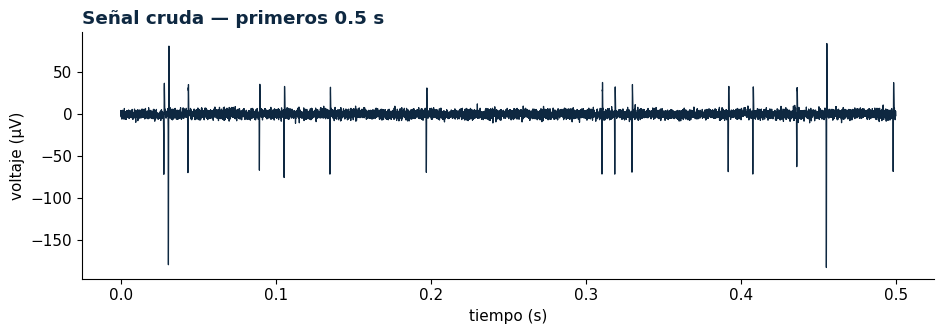

In [3]:
def ver(x, titulo, t0=0.0, t1=0.5, color=NAVY):
    """Grafica la señal x entre los tiempos t0 y t1 (en segundos)."""
    m = (t >= t0) & (t < t1)                  # máscara: True donde el tiempo cae en la ventana
    plt.figure()
    plt.plot(t[m], x[m], color=color, lw=0.9)   # ¿qué va en el eje x y qué en el eje y?
    plt.title(titulo, color=NAVY, fontweight="bold", loc="left")
    plt.xlabel("tiempo (s)")                          # no olvides las unidades
    plt.ylabel("voltaje (µV)")

ver(senal, "Señal cruda — primeros 0.5 s")

✅ **Revisa tu figura a ojo.** Debe cumplir las cuatro cosas:

- [✅] Se ve **medio segundo** de registro, no los dos segundos completos.
- [✅] El eje horizontal dice *tiempo (s)* y el vertical *voltaje (µV)*.
- [✅] Los picos apuntan **hacia abajo**.
- [✅] Se distinguen picos de **dos tamaños**.

Si alguna falla, arregla la función antes de seguir: todo lo que viene la usa.

**Pregunta 1.** Mirando la figura:

- ¿Hacia dónde apunta el pico de los spikes, arriba o abajo? ¿Por qué crees que es así?
- ¿Cuántos spikes **grandes** cuentas a ojo en esos 0.5 s? ¿Cuadra con los 8 spikes/s de la tabla?

_Escribe tu respuesta aquí:_

1. El pico de los spikes apuntan hacia abajo alcanzando valores de voltaje negativos alejandose de la linea de referencia, lo que indica que tienen una polaridad negativa.

2. Hay 15 spikes **grandes**, esto no cuadra con los 8 de la tabla, los cuales pueden corresponder a ruidos.


---
## 3 · Poner un umbral

Detectar un spike = decidir **cuándo la señal se aleja demasiado de la línea de base**.

Como el pico de estos spikes es **negativo**, buscamos cruces por debajo de un umbral negativo.
¿Y dónde se pone ese umbral? Necesitas saber **qué tan grande es el ruido**: el umbral tiene que
quedar por fuera del ruido, pero por dentro del spike más pequeño.

La forma más directa de averiguarlo es medir el ruido **donde sabes que no hay spikes**. En este
registro los primeros **20 ms** son línea de base: el primer spike ocurre después. Ahí, lo más
lejos de cero que llega la señal es puro ruido.

> 📌 Existe una forma más fina de cuantificar el ruido — la **desviación estándar** y su versión
> robusta, el **MAD** — pero requiere estadística que todavía no hemos visto. La trabajaremos en la
> **Sesión 4**, cuando el ruido deje de ser despreciable y esta regla sencilla empiece a fallar.

### 📋 Ejercicio 2 — Pega este prompt

Copia este prompt **tal cual** en ChatGPT o Claude. Lee la respuesta completa antes de usarla.

> Trabajo en Python con numpy. Tengo dos arrays de la misma longitud: `t` con tiempos en segundos
> y `senal` con el voltaje en µV de un registro extracelular muestreado a 20000 Hz; los spikes
> aparecen como picos **negativos**. Los primeros 20 ms del registro son línea de base: ahí no hay
> ningún spike. Quiero tres cosas, en tres líneas: (1) seleccionar esa ventana inicial usando `t`;
> (2) medir cuánto se aleja de cero el ruido en esa ventana, en valor absoluto; (3) fijar un umbral
> de detección **negativo**, igual a k veces ese valor, con k = 2. No uses `np.std` ni ninguna
> constante estadística. Explícame por qué conviene medir el ruido en una ventana sin spikes en
> lugar de en todo el registro.

Antes de correr nada, contesta: **¿el código que te dio sirve, o le sobra o le falta algo?**

R// Si sirve ya que selecciona una base inicial, luego mide cuanto se aleja el ruido del 0 para asi definir que cuenta como spike y que no.

ruido en la línea de base ≈ 9.8 µV
umbral = -2 × ruido = -19.5 µV


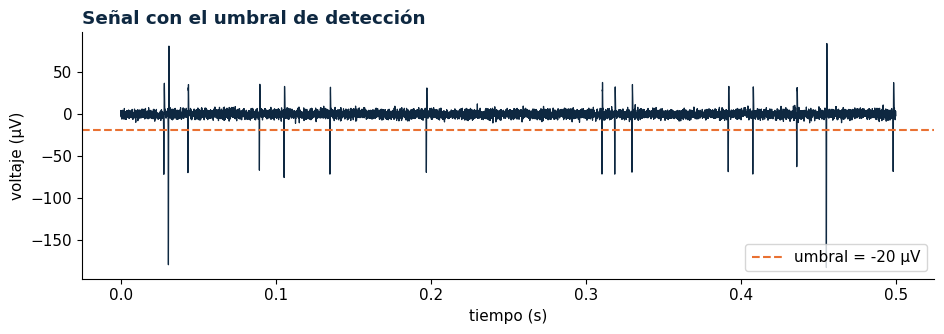

In [4]:
# Escribe aquí el código (el de la IA, corregido por ti, o el tuyo).

# 1. Seleccionamos la ventana inicial (primeros 20 ms) usando t
base = senal[t < 0.020]

# Al final deben quedar definidas estas tres variables:

ruido  = np.max(np.abs(base))      # lo más lejos de cero que llega el ruido en la línea de base, en µV
k      = 2                         # cuántas veces ese ruido exigimos para llamar spike a algo
umbral = -k * ruido                 # el umbral de detección, en µV (negativo)

print(f"ruido en la línea de base ≈ {ruido:.1f} µV")
print(f"umbral = -{k} × ruido = {umbral:.1f} µV")

# Grafica la señal con el umbral encima (usa la función que hiciste en el ejercicio 1)
ver(senal, "Señal con el umbral de detección", 0.0, 0.5)
plt.axhline(umbral, color=ORANGE, ls="--", lw=1.5, label=f"umbral = {umbral:.0f} µV")
plt.legend(loc="lower right")

In [5]:
# ✅ VERIFICACIÓN — ejercicio 2
print("Por comparación, el pico más negativo de todo el registro:",
      round(float(senal.min()), 1), "µV\n")

revisar("mediste el ruido en la línea de base, no en todo el registro",
        8 < ruido < 12,
        "si te dio más de 100 µV estás midiendo un spike: la ventana son los primeros 20 ms")
revisar("el umbral es negativo",
        umbral < 0,
        "los spikes de este registro apuntan hacia abajo")
revisar("el umbral es k veces el ruido",
        abs(umbral + k*ruido) < 0.5)
revisar("el umbral queda por fuera del ruido",
        umbral < -12,
        "si el umbral cae dentro del rango del ruido, vas a detectar ruido como si fueran spikes")
revisar("el umbral deja pasar los spikes pequeños (~70 µV)",
        umbral > -60,
        "si el umbral es más negativo que -70 µV, la neurona B no lo cruza nunca")

Por comparación, el pico más negativo de todo el registro: -184.7 µV

  OK    mediste el ruido en la línea de base, no en todo el registro
  OK    el umbral es negativo
  OK    el umbral es k veces el ruido
  OK    el umbral queda por fuera del ruido
  OK    el umbral deja pasar los spikes pequeños (~70 µV)


**Pregunta 2.** Cambia `k` a **0.5** y luego a **8**, y vuelve a ejecutar las dos celdas anteriores.

- Con `k = 0.5`, ¿el umbral corta algo que **no** es un spike? ¿Cómo se llama ese tipo de error?

R// En este caso el umbral queda muy cerca a 0 dejandolo dentro del rango normal del ruido, lo que hace que el detector empieza a marcar como **spike** cosas que enrealidad solo son ruido, este error se le conoce como **falso positivo**

- Con `k = 8`, ¿qué neurona desaparece del registro y por qué?

R// En este caso el umbral esta muy alejado del 0 y como los spikes de la neurona B son pequeños no alcanzan a cruzarlo; asi que la **neurona B** desaparece, y la neurona A sigue detectandose porque sus spikes son bastante grandes para superar dicho umbral.

- Entre esos dos extremos hay un rango amplio de valores de `k` que dan **exactamente el mismo
  resultado**. Compruébalo. ¿Por qué esta señal perdona tanto, y en qué situación dejaría de hacerlo?

R// La señal perdona tanto mientas que el umbral caiga en cualquier punto dentro de esa brecha, el resultado es el mismo, todo ruido queda afuera y todos los spikes quedan dentro sin importar el valor exacto de k. Por otro lado, esta situacion cambia si el ruido es mas grande o si hubiera una neurona con spikes mas chiquitos.


> Cuando termines, **deja `k` en el valor que elegiste** y vuelve a ejecutar las dos celdas antes de continuar.

---
## 4 · De los cruces a los tiempos de spike

Un problema práctico: un solo spike dura ~1.6 ms y a 20 kHz eso son **32 muestras seguidas**
más negativas que el umbral. Si contaras cada muestra tendrías 32 "spikes" donde hay uno.

La solución: quedarse con el **primer** cruce, buscar el mínimo ahí cerca, y luego ignorar una
ventana corta — un *período muerto* de ~2 ms, inspirado en el período refractario real de la neurona.

### ✍️ Ejercicio 3 — Escribe tu prompt

Esta es la función más difícil del taller, y la vas a pedir tú. Especificación de lo que debe hacer:

| | |
|---|---|
| **Entradas** | `x` (array de voltaje), `umbral` (número negativo), `muerto_ms=2.0`, `fs=FS` |
| **Salida** | un array de **índices** (no de tiempos), uno por spike detectado |
| **Cómo** | encontrar todos los índices donde `x` está por debajo del umbral; tomar el primero; buscar el **mínimo** dentro de la ventana del período muerto; guardar ese índice; saltar al primer cruce que ocurra después de la ventana y repetir |

Antes de escribir el prompt, repasa los **5 elementos** del principio del taller. Un prompt que
solo diga *"hazme un detector de spikes"* te va a devolver algo que no encaja con estos datos.

_Escribe aquí el prompt que le vas a dar a la IA:

Trabajo en Python con numpy. Tengo un array `x` con el voltaje de una señal, un `umbral` negativo, un período muerto `muerto_ms = 2.0` ms y una frecuencia de muestreo `fs = FS`; los spikes aparecen como picos negativos. Quiero detectar los spikes recorriendo la señal: primero encontrar todos los índices donde `x` esté por debajo del `umbral`, tomar el primero como candidato y, dentro de la ventana correspondiente a los 2 ms siguientes, buscar el mínimo de la señal y guardar el índice donde aparece ese mínimo como el spike detectado. Después de esa ventana, quiero continuar la búsqueda desde el primer cruce del umbral que ocurra después del período muerto y repetir el procedimiento hasta recorrer toda la señal. La salida debe ser un array de índices, no de tiempos, con un índice por cada spike detectado. Usa numpy y no agregues librerías innecesarias; explica qué hace cada parte del código y cómo se convierte el período muerto de milisegundos a número de muestras.


>

**¿Qué líneas del código no entiendes?** Pregúntale a la IA en la misma conversación:
*"¿Qué hace esta línea de código: (pega la línea)?"*

>

_¿Qué le tuviste que corregir a la respuesta?_

>

In [6]:
def detectar(x, umbral, muerto_ms=2.0, fs=FS):
    """Devuelve los índices del pico (mínimo) de cada spike que cruza el umbral."""
    # tu código aquí
    # convertir el periodo muerto de milisegundos a numero de muestras
    muestras_muerto = int(muerto_ms/1000*fs)
    # encontrar indices donde la señal esta por debajo del umbral
    cruces = np.where(x < umbral)[0]

    spikes = []
    i = 0

    while i < len(cruces):
      idx_candidato = cruces[i]
      # ventana de 'muestras_muerto' puntos a partir del candidato, sin pasarnos del final de x
      fin_ventana = min(idx_candidato + muestras_muerto, len(x))
      ventana = x[idx_candidato:fin_ventana]

      idx_minimo = idx_candidato + np.argmin(ventana)  # índice del valor más negativo dentro de la ventana
      spikes.append(idx_minimo)                        # ese es el spike real: el pico más profundo

      # saltamos al primer cruce que ocurra después del período muerto
      limite = idx_candidato + muestras_muerto
      i = np.searchsorted(cruces, limite)
    return np.array(spikes)

    ...


idx        = detectar(senal, umbral)   # índices de muestra
tiempos    = t[idx]                    # índices -> tiempos, en segundos
amplitudes = senal[idx]                # voltaje del pico de cada spike, en µV

print("spikes detectados:", len(idx))
print("Primeros 5 tiempos (s):", np.round(tiempos[:5], 4))

spikes detectados: 55
Primeros 5 tiempos (s): [0.0278 0.0308 0.0434 0.0895 0.1054]


In [7]:
# ✅ VERIFICACIÓN — ejercicio 3
idx = np.asarray(idx)

revisar("detectar() devuelve índices enteros, no tiempos",
        idx.dtype.kind in "iu" and idx.max() < len(senal),
        "los índices son posiciones en el array; los tiempos salen después, con t[idx]")
revisar("el número de spikes detectados es plausible (entre 50 y 60)",
        50 <= len(idx) <= 60,
        "si te salen cientos, no estás aplicando el período muerto; si te salen ~16, tu umbral es muy exigente")
revisar("cada índice cae por debajo del umbral",
        bool(np.all(senal[idx] < umbral)),
        "estás guardando el índice del cruce o de la ventana, no el del mínimo")
revisar("no hay dos detecciones separadas por menos del período muerto",
        bool(np.all(np.diff(tiempos) >= 0.0019)),
        "después de detectar un spike tienes que saltar 2 ms hacia adelante")
revisar("los índices salen ordenados en el tiempo",
        bool(np.all(np.diff(idx) > 0)))

  OK    detectar() devuelve índices enteros, no tiempos
  OK    el número de spikes detectados es plausible (entre 50 y 60)
  OK    cada índice cae por debajo del umbral
  OK    no hay dos detecciones separadas por menos del período muerto
  OK    los índices salen ordenados en el tiempo


📋 **Y ahora pega este prompt**, con tu propia función:

> Este código detecta spikes negativos con un umbral y un período muerto de 2 ms:
> [pega aquí tu función `detectar`]
> Explícame qué pasaría si dos neuronas dispararan con menos de 2 ms de diferencia.
> ¿Qué error cometería el detector y cómo se llama ese problema en electrofisiología?

_Resume en una frase lo que aprendiste de la respuesta:_

R// un período muerto de 2 ms puede hacer que dos spikes muy cercanos se detecten como uno solo, provocando que algunos spikes reales no sean contados.


>

---
## 5 · Separar las dos neuronas

Ya tenemos **todos** los spikes mezclados. Para saber cuál es de cuál usamos lo único que las
distingue: la **amplitud del pico**.

Si el histograma de amplitudes tiene **dos montones separados**, podemos cortar en el valle.

### ✏️ Ejercicio 4 — Completa el código

Text(0.0, 1.0, 'Histograma de amplitudes: ¿cuántos grupos ves?')

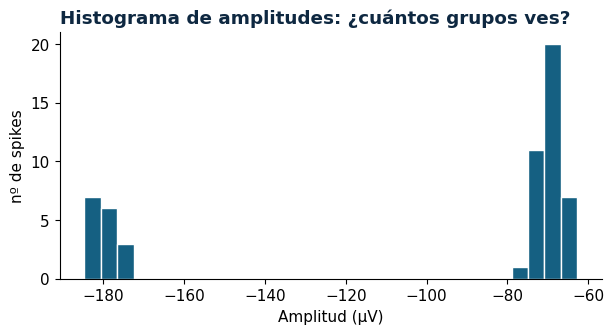

In [8]:
plt.figure(figsize=(7, 3.2))
plt.hist(amplitudes, bins=30, color=TEAL, edgecolor="white")   # ¿qué variable contiene las amplitudes?
plt.xlabel("Amplitud (µV)")                                       # con unidades
plt.ylabel("nº de spikes")
plt.title("Histograma de amplitudes: ¿cuántos grupos ves?",
          color=NAVY, fontweight="bold", loc="left")

In [9]:
corte = -120          # µV — léelo del valle del histograma de arriba

es_A = amplitudes < corte     # ¿< o >? los spikes de A son los MÁS negativos
es_B = ~es_A                     # ~ invierte la máscara: todo lo que no es A

tiempos_A_det = tiempos[es_A]
tiempos_B_det = tiempos[es_B]

print(f"Neurona A (grande):  {len(tiempos_A_det)} spikes")
print(f"Neurona B (pequeña): {len(tiempos_B_det)} spikes")

Neurona A (grande):  16 spikes
Neurona B (pequeña): 39 spikes


In [10]:
# ✅ VERIFICACIÓN — ejercicio 4
revisar("el corte cae entre los dos montones del histograma",
        float(amplitudes.min()) < corte < float(amplitudes.max()),
        "míralo otra vez en el histograma: tiene que caer en el valle, no en un extremo")
revisar("cada spike quedó asignado a una sola neurona",
        len(tiempos_A_det) + len(tiempos_B_det) == len(tiempos))
revisar("el grupo A tiene tantos spikes como los que generamos",
        len(tiempos_A_det) == len(tiempos_A),
        "si te da al revés, revisa el signo de la comparación: A es la MÁS negativa")
revisar("el grupo A es en promedio más grande que el B",
        amplitudes[es_A].mean() < amplitudes[es_B].mean())

  OK    el corte cae entre los dos montones del histograma
  OK    cada spike quedó asignado a una sola neurona
  OK    el grupo A tiene tantos spikes como los que generamos
  OK    el grupo A es en promedio más grande que el B


**Pregunta 3.** ¿Qué pasaría si las dos neuronas estuvieran a distancias **parecidas** del
electrodo?

- Describe cómo se vería el histograma de amplitudes en ese caso.
- Explica por qué el método de arriba fallaría.
- ¿Qué otra característica del spike (además de la amplitud) podrías usar para separarlas?

_Escribe tu respuesta aquí:_
R// En el histograma se verian dos grupos muy pegados y no se podria poner el corte porque las amplitudes de ambas neuronas ocuparian un rango de voltaje muy similar. Por otro lado, el metodo fallaria porque este depende de que exista una separacion clara entre las neuronas ya que en caso de estar muy juntas y elegir mal el corte se podrian causar muchos falsos positivos. Finalmente, además de la amplitud se podría usar la forma completa del spike, ya que cada neurona tiene una forma de onda característica que no depende solo de qué tan cerca está del electrodo. Comparando esa forma completa  es posible separar neuronas aunque su amplitud sea parecida.

### ✍️ Ejercicio 5 — Escribe tu prompt

Ahora quieres **una figura que demuestre que la separación funcionó**: los primeros 0.5 s de la
señal, en gris, con un marcador triangular sobre el pico de cada spike — naranja para la neurona A,
azul para la neurona B — y una leyenda.

Redáctalo tú. Acuérdate de decirle qué variables tienes ya (`t`, `senal`, `tiempos_A_det`,
`tiempos_B_det`, `amplitudes`, `es_A`, `es_B`) y qué colores usa el curso.

_Escribe aquí tu prompt:_

R// Trabajo en Python con numpy y matplotlib. Ya tengo las variables `t`, `senal`, `tiempos_A_det`, `tiempos_B_det`, `amplitudes`, `es_A` y `es_B`, donde `t` contiene los tiempos de la señal, `senal` el voltaje, `tiempos_A_det` y `tiempos_B_det` los tiempos de los spikes detectados para las neuronas A y B, `amplitudes` las amplitudes de los spikes y `es_A` y `es_B` indican a qué neurona pertenece cada spike. Quiero crear una figura que demuestre visualmente que la separación de las dos neuronas funcionó: mostrar únicamente los primeros 0.5 s de `senal` en color gris y colocar un marcador triangular sobre el pico de cada spike detectado, usando naranja para la neurona A y azul para la neurona B, que son los colores establecidos por el curso. Incluye una leyenda que indique claramente qué color corresponde a cada neurona, etiqueta los ejes con sus unidades y usa los tiempos y amplitudes de las variables que ya tengo, sin volver a detectar los spikes.

>

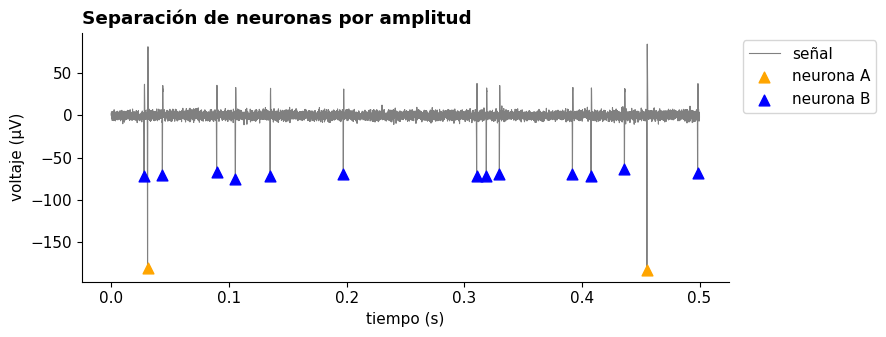

In [11]:
# Pega aquí el código de tu figura y ajústalo hasta que se vea bien.
import matplotlib.pyplot as plt  # Librería para graficar
import numpy as np               # Para las máscaras booleanas

t0, t1 = 0.0, 0.5  # ventana de tiempo a mostrar, en segundos

# Amplitudes correspondientes a cada neurona, en el mismo orden que tiempos_A_det / tiempos_B_det
amplitudes_A = amplitudes[es_A]
amplitudes_B = amplitudes[es_B]

# Máscaras para quedarnos solo con los spikes dentro de la ventana de 0.5 s
m_A = (tiempos_A_det >= t0) & (tiempos_A_det < t1)
m_B = (tiempos_B_det >= t0) & (tiempos_B_det < t1)

# Máscara para la señal cruda, misma ventana
m_senal = (t >= t0) & (t < t1)

plt.figure(figsize=(9, 3.5))

# Señal cruda en gris, de fondo
plt.plot(t[m_senal], senal[m_senal], color="gray", lw=0.8, label="señal")

# Marcadores triangulares sobre el pico de cada spike detectado
plt.scatter(tiempos_A_det[m_A], amplitudes_A[m_A],
            marker="^", color="orange", s=60, zorder=3, label="neurona A")
plt.scatter(tiempos_B_det[m_B], amplitudes_B[m_B],
            marker="^", color="blue", s=60, zorder=3, label="neurona B")

plt.xlabel("tiempo (s)")      # unidades del eje x
plt.ylabel("voltaje (µV)")    # unidades del eje y
plt.title("Separación de neuronas por amplitud", fontweight="bold", loc="left")
# Leyenda afuera del gráfico, a la derecha, así nunca tapa ningún pico
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))

plt.tight_layout()

✅ **Revisa tu figura a ojo:**

- [✅] Los triángulos caen **encima** de los picos, no flotando en el aire ni desplazados.
- [✅] Todos los picos grandes son de un color y todos los pequeños del otro.
- [✅] Hay leyenda, y los ejes tienen unidades.

---
## 6 · La tasa de disparo

$$\text{tasa de disparo (Hz)} = \frac{\text{número de spikes}}{\text{duración del registro (s)}}$$

Es la medida más básica de actividad neuronal y la vas a usar todo el semestre.

### ✏️ Ejercicio 6 — Completa el código

Neurona A: 8.0 spikes/s
Neurona B: 19.5 spikes/s


Text(0.0, 1.0, 'Tasa de disparo')

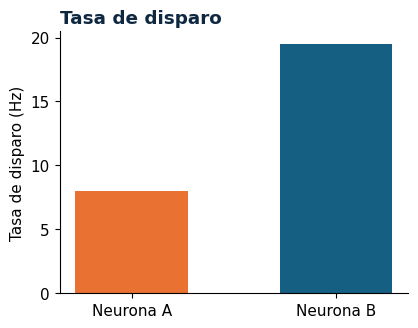

In [12]:
tasa_A = (len(tiempos_A_det)) / DUR
tasa_B = (len(tiempos_B_det)) / DUR

print(f"Neurona A: {tasa_A:.1f} spikes/s")
print(f"Neurona B: {tasa_B:.1f} spikes/s")

plt.figure(figsize=(4.5, 3.4))
plt.bar(["Neurona A", "Neurona B"], [tasa_A, tasa_B], color=[ORANGE, TEAL], width=0.55)
plt.ylabel("Tasa de disparo (Hz)")                     # con unidades
plt.title("Tasa de disparo", color=NAVY, fontweight="bold", loc="left")

In [13]:
# ✅ VERIFICACIÓN — ejercicio 6
revisar("tasa_A son spikes por segundo, no un conteo",
        abs(tasa_A - len(tiempos_A_det)/DUR) < 0.01,
        "dividiste por el número equivocado: la duración del registro está en DUR")
revisar("tasa_B son spikes por segundo, no un conteo",
        abs(tasa_B - len(tiempos_B_det)/DUR) < 0.01)
revisar("la neurona B dispara más rápido que la A",
        tasa_B > tasa_A,
        "ojo: B es la pequeña en amplitud, pero la rápida en tasa")

  OK    tasa_A son spikes por segundo, no un conteo
  OK    tasa_B son spikes por segundo, no un conteo
  OK    la neurona B dispara más rápido que la A


---
## 7 · ¿Le acertamos?

La ventaja de trabajar con datos simulados: **conocemos la respuesta correcta**. Comparemos lo
detectado con los tiempos que generamos en el paso 1.

### ✏️ Ejercicio 7 — Completa el código

In [14]:
print(f"{'':12} {'real':>8} {'detectado':>12}")
print(f"{'Neurona A':12} {len(tiempos_A):8} {len(tiempos_A_det):12}")
print(f"{'Neurona B':12} {len(tiempos_B):8} {len(tiempos_B_det):12}")

# ¿Cuán lejos quedó cada tiempo detectado del tiempo real más cercano? (en ms)
err = [np.min(np.abs(tiempos_A - ts))*1000 for ts in tiempos_A_det]
print(f"\nError temporal mediano en la neurona A: {np.median(err):.2f} ms")

                 real    detectado
Neurona A          16           16
Neurona B          40           39

Error temporal mediano en la neurona A: 0.63 ms


Ese error mediano **no es cero**, y no es un fallo: `poner_spikes` coloca el *inicio* del spike
en el tiempo verdadero, mientras que `detectar` devuelve el instante del **mínimo**, que llega
un poco después. Es un desfase sistemático, no ruido.

Falta **un** spike de la neurona B. ¿Dónde se perdió? Hay dos sospechosos:

1. Un spike que quedó justo por **encima** del umbral y no lo cruzó.
2. Dos spikes que cayeron dentro del mismo **período muerto** y se contaron como uno.

Completa la celda siguiente para revisar el segundo sospechoso.

In [15]:
todas_reales = np.sort(np.concatenate([tiempos_A, tiempos_B])) #tiempos_A y timepos_B están en segundos
isi = np.diff(todas_reales) * 1000          # intervalos entre spikes consecutivos, en MILISEGUNDOS

colisiones = np.where(isi < 2.0)[0]        # ¿cuál es el período muerto de tu detector, en ms?
print("Pares de spikes separados por menos del período muerto:", len(colisiones))
for i in colisiones:
    print(f"  t = {todas_reales[i]:.4f} s  y  {todas_reales[i+1]:.4f} s"
          f"  ->  {isi[i]:.2f} ms de diferencia")

Pares de spikes separados por menos del período muerto: 1
  t = 1.0122 s  y  1.0137 s  ->  1.49 ms de diferencia


In [16]:
# ✅ VERIFICACIÓN — ejercicio 7
revisar("isi está en milisegundos",
        1 < float(np.median(isi)) < 200,
        "si la mediana te da ~0.03, todavía está en segundos")
revisar("encontraste al menos una colisión",
        len(colisiones) >= 1,
        "compara contra el período muerto que usaste en detectar(), en ms")
revisar("el total detectado y el total real se diferencian en pocos spikes",
        abs(len(tiempos) - (len(tiempos_A) + len(tiempos_B))) <= 3)

  OK    isi está en milisegundos
  OK    encontraste al menos una colisión
  OK    el total detectado y el total real se diferencian en pocos spikes


**Pregunta 4 (cierre).** Con el resultado de arriba:

- ¿Cuál de los dos sospechosos explica el spike perdido? ¿Cómo lo sabes?

R// la colision de spikes ya que estan separados por 1.49 ms, menos que el periodo muerto de 2 ms por lo que el detector los tomo como uno solo.  

- Si bajaras el período muerto a 0.5 ms, ¿recuperarías ese spike? ¿Qué problema nuevo aparecería?

R// Si, pero podria causar que un mismo spike se cuente dos veces, ya que esto seria menor que la duracion del spike.

- Perdiste 1 de 56 spikes. ¿En qué tipo de análisis daría igual, y en cuál sería inaceptable?

R// Perder 1 de 56 spikes podria ser muy poco importante para la tasa de disparo promedio, pero seria importante para analizar timing, ISI, sincronia o rafagas.

---
## Lo que hiciste hoy

Recorriste el pipeline completo con la señal **fácil**, y esta vez lo escribiste tú:

`voltaje(t)` → umbral → `tiempos de spike` → separación por amplitud → **tasa de disparo**

## Lo que rompe este pipeline (Sesión 4)

Los datos reales del laboratorio **no** se ven así. Van a tener:

- ruido de la red eléctrica a 60 Hz, que sube y baja la línea de base;
- deriva lenta (LFP) que hace que un umbral fijo detecte de más en unas partes y de menos en otras;
- ruido térmico mucho mayor, que puede tapar por completo a la neurona B.

Cuando eso pase, medir el ruido con el máximo de una ventana dejará de servir: un solo artefacto
te arruina la estimación. Ahí entran la **desviación estándar** y el **MAD**, que veremos en la
Sesión 4 junto con el filtrado.

En la próxima sesión veremos por qué **filtrar antes de detectar** deja de ser opcional.

### ✍️ Prompt para llevarte a casa

Escríbelo tú, con los 5 elementos. Debe pedirle a la IA que tome esta misma señal, le añada
ruido de 60 Hz y una deriva lenta, y te muestre qué le pasa a tu detección.

_Tu prompt:_

>

_Corre lo que te dé y anota en una frase qué le pasó a tu detector:_

>

---
## Antes de subir a GitHub

- [ ] El notebook corre **de arriba abajo sin errores** (Entorno de ejecución → Reiniciar y ejecutar todo).
- [ ] No queda ningún `____` sin llenar.
- [ ] Todas las verificaciones dicen `OK`.
- [ ] Las cuatro preguntas están respondidas **con tus palabras**.
- [ ] Los tres prompts que escribiste tú están en el notebook.
- [ ] El archivo se llama `Practica_S3_ApellidoUno_ApellidoDos.ipynb`.

⚠️ Recuerda: **nunca pegues código que no puedas explicar en voz alta.**